In [1]:
import numpy as np

np.random.seed(42)
X = np.random.rand(10, 2)

print("Generated Coordinates:")
print(X)
print("Array Shape:", X.shape)

Generated Coordinates:
[[0.37454012 0.95071431]
 [0.73199394 0.59865848]
 [0.15601864 0.15599452]
 [0.05808361 0.86617615]
 [0.60111501 0.70807258]
 [0.02058449 0.96990985]
 [0.83244264 0.21233911]
 [0.18182497 0.18340451]
 [0.30424224 0.52475643]
 [0.43194502 0.29122914]]
Array Shape: (10, 2)


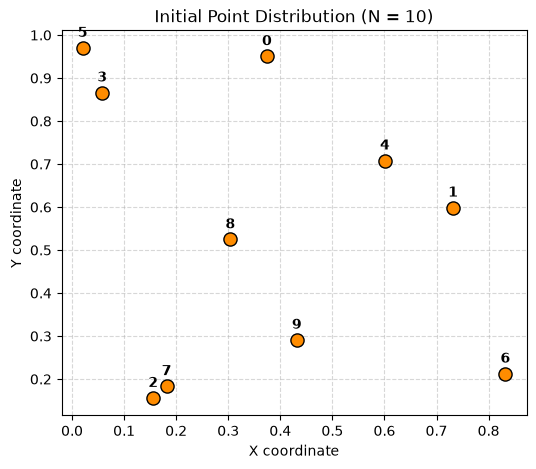

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], color="darkorange", s=90, edgecolors="black", zorder=3)
for idx, (x_val, y_val) in enumerate(X):
    plt.annotate(
        str(idx),
        (x_val, y_val),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontweight="bold",
    )
plt.title("Initial Point Distribution (N = 10)")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [5]:
D2 = np.sum(
    (X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2,
    axis=2
)
print("Squaed Distance Matrix:")
print(D2)
print("Shape:", D2.shape)


Squaed Distance Matrix:
[[0.         0.25171654 0.67933117 0.10729142 0.11021119 0.12565305
  0.75487265 0.62590345 0.1863819  0.43821601]
 [0.25171654 0.         0.52769893 0.52572083 0.02910074 0.64393098
  0.1593326  0.47512176 0.18843303 0.18454216]
 [0.67933117 0.52769893 0.         0.51394921 0.50290096 0.68080058
  0.46072414 0.00141727 0.15795558 0.09442377]
 [0.10729142 0.52572083 0.51394921 0.         0.31987984 0.01216687
  1.02713477 0.48148903 0.17716149 0.47033641]
 [0.11021119 0.02910074 0.50290096 0.31987984 0.         0.40557444
  0.29926414 0.45108072 0.12173825 0.20237694]
 [0.12565305 0.64393098 0.68080058 0.01216687 0.40557444 0.
  1.23302708 0.64458914 0.27862329 0.62982499]
 [0.75487265 0.1593326  0.46072414 1.02713477 0.29926414 1.23302708
  0.         0.42414057 0.37660024 0.16662198]
 [0.62590345 0.47512176 0.00141727 0.48148903 0.45108072 0.64458914
  0.42414057 0.         0.13150712 0.07418619]
 [0.1863819  0.18843303 0.15795558 0.17716149 0.12173825 0.27862

In [6]:
diagonal = np.diag(D2)

print("Diagonal:")
print(diagonal)

print("All diagonal values are zero:",
      np.allclose(diagonal, 0))


Diagonal:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
All diagonal values are zero: True


In [7]:
neighbor_order = np.argsort(D2, axis=1)

print("Neighbour ordering:")
print(neighbor_order)


Neighbour ordering:
[[0 3 4 5 8 1 9 7 2 6]
 [1 4 6 9 8 0 7 3 2 5]
 [2 7 9 8 6 4 3 1 0 5]
 [3 5 0 8 4 9 7 2 1 6]
 [4 1 0 8 9 6 3 5 7 2]
 [5 3 0 8 4 9 1 7 2 6]
 [6 1 9 4 8 7 2 0 3 5]
 [7 2 9 8 6 4 1 3 0 5]
 [8 9 4 7 2 3 0 1 5 6]
 [9 8 7 2 6 1 4 0 3 5]]


In [8]:
K = 2

nearest_neighbors = neighbor_order[:, 1:K+1]

print("Two nearest neighbours:")
print(nearest_neighbors)


Two nearest neighbours:
[[3 4]
 [4 6]
 [7 9]
 [5 0]
 [1 0]
 [3 0]
 [1 9]
 [2 9]
 [9 4]
 [8 7]]


In [10]:
K = 2

partitioned = np.argpartition(
    D2,
    K + 1,
    axis=1
)

candidate_neighbors = partitioned[:, :K+1]

print("Candidate indices:")
print(candidate_neighbors)


Candidate indices:
[[0 3 4]
 [1 4 6]
 [2 7 9]
 [3 5 0]
 [4 1 0]
 [5 3 0]
 [6 1 9]
 [7 2 9]
 [8 9 4]
 [9 8 7]]


In [11]:
nearest_neighbors_partition = (
    candidate_neighbors[:, 1:K+1]
)

print("Two nearest neighbours:")
print(nearest_neighbors_partition)


Two nearest neighbours:
[[3 4]
 [4 6]
 [7 9]
 [5 0]
 [1 0]
 [3 0]
 [1 9]
 [2 9]
 [9 4]
 [8 7]]


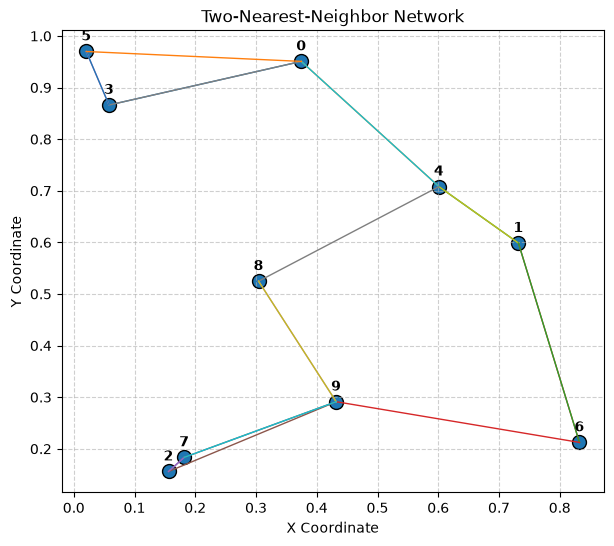

In [12]:
plt.figure(figsize=(7, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=100,
    edgecolors="black"
)

# Label points
for i, (x, y) in enumerate(X):
    plt.annotate(
        str(i),
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontweight="bold"
    )

# Draw connections
for i in range(len(X)):
    for j in nearest_neighbors[i]:
        plt.plot(
            [X[i, 0], X[j, 0]],
            [X[i, 1], X[j, 1]],
            linewidth=1
        )

plt.title("Two-Nearest-Neighbor Network")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


In [16]:
def loop_knn(points, k=2):
    """Loop version: computes and sorts the distances of ONE point at a time."""
    n = points.shape[0]
    result = np.zeros((n, k), dtype=int)
    for i in range(n):
        diff = points - points[i]
        distances = np.sum(diff ** 2, axis=1)
        result[i] = np.argsort(distances)[1:k + 1]
    return result

def vectorized_knn(points, k=2):
    """Vectorized version: all distances at once with broadcasting."""
    diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]
    distances = np.sum(diff ** 2, axis=-1)
    return np.argsort(distances, axis=1)[:, 1:k + 1]

test_data = np.random.default_rng(0).random((100, 2))
print("Same result?", np.array_equal(loop_knn(test_data), vectorized_knn(test_data)))



Same result? True


In [19]:
pts_100 = np.random.default_rng(0).random((100, 2))
pts_1000 = np.random.default_rng(0).random((1000, 2))
pts_5000 = np.random.default_rng(0).random((5000, 2))
%timeit loop_knn(pts_5000)
%timeit vectorized_knn(pts_5000)

5.49 s ± 843 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
5.16 s ± 632 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [21]:
from sklearn.neighbors import KDTree 
pts = np.random.default_rng(0).random((1000, 2)) 
def kdtree_knn(points, k=2): 
    tree = KDTree(points)
    _, idx = tree.query(points, k=k + 1)   # k+1 because the point is its own neighbour 
    return idx[:, 1:] 
print("Same neighbours as NumPy?", np.array_equal(kdtree_knn(pts), vectorized_knn(pts))) 


Same neighbours as NumPy? True
